<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/Tri_Dataset_ETD_Optimization_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading London dataset...
Generating synthetic 'FLAG' labels using Isolation Forest...
Class Distribution:
FLAG
0    46000
1     4000
Name: count, dtype: int64

Performing Leakage-Free Group Split (Grouped by LCLid)...

Starting Model Training and Hyperparameter Optimization...


Optimizing Models: 100%|██████████| 3/3 [04:47<00:00, 95.96s/it]




Evaluating Models on Leakage-Free Test Set...


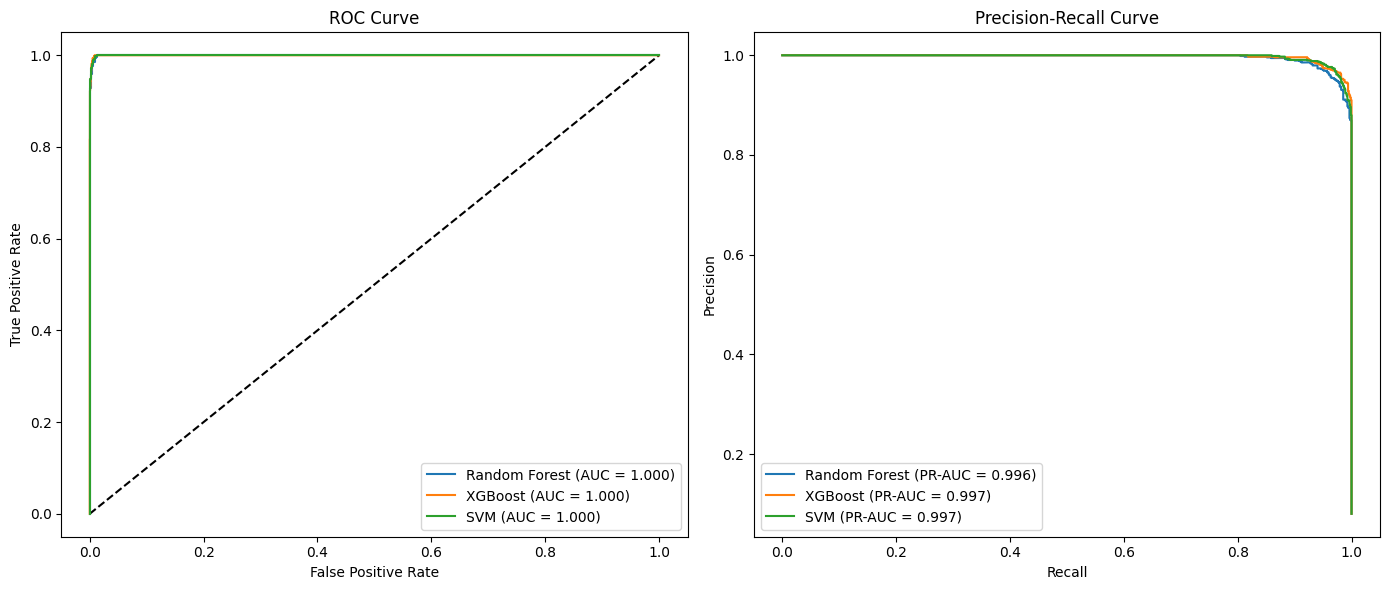


Performance Metrics:
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
      XGBoost  0.994613   0.946324 0.989024  0.967203 0.999752 0.997158
Random Forest  0.993634   0.954272 0.967073  0.960630 0.999601 0.995536
          SVM  0.992067   0.915636 0.992683  0.952604 0.999724 0.996910


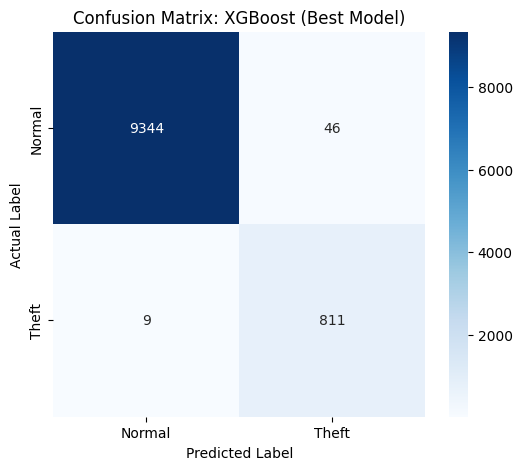

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD DATA & GENERATE SYNTHETIC LABELS
# ==========================================
print("Loading London dataset...")
df = pd.read_csv("London - minimize dataset.csv")

# Generate Synthetic Labels (Since FLAG is missing in the uploaded CSV)
# We assume the top 8% most anomalous energy behaviors represent meter tampering/theft
print("Generating synthetic 'FLAG' labels using Isolation Forest...")
features_for_iso = df.drop(columns=['LCLid', 'day'])
iso = IsolationForest(contamination=0.08, random_state=42, n_jobs=-1)
df['FLAG'] = iso.fit_predict(features_for_iso)
df['FLAG'] = df['FLAG'].apply(lambda x: 1 if x == -1 else 0)

print(f"Class Distribution:\n{df['FLAG'].value_counts()}")

# ==========================================
# 2. LEAKAGE-FREE SPLIT & PREPROCESSING
# ==========================================
print("\nPerforming Leakage-Free Group Split (Grouped by LCLid)...")

# Define features and target
X = df.drop(columns=['FLAG', 'LCLid', 'day']) # Drop identifiers to prevent memorization
y = df['FLAG']
groups = df['LCLid'] # The grouping variable

# GroupShuffleSplit ensures a single household is entirely in train OR test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Robust Scaling (Best for outlier-heavy energy data)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. MODEL DEFINITION & OPTIMIZATION
# ==========================================
print("\nStarting Model Training and Hyperparameter Optimization...")

# Define models and their parameter grids for RandomizedSearch
models_params = {
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42),
        {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", scale_pos_weight=11, random_state=42),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
    ),
    "SVM": (
        SVC(class_weight="balanced", probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1, 0.01]}
    )
}

best_models = {}

# Use tqdm to show progress across the 3 models
for name, (model, params) in tqdm(models_params.items(), desc="Optimizing Models"):
    search = RandomizedSearchCV(model, params, n_iter=5, scoring='f1', cv=3, n_jobs=-1, random_state=42)
    search.fit(X_train_scaled, y_train)
    best_models[name] = search.best_estimator_

# ==========================================
# 4. EVALUATION & VISUALIZATION
# ==========================================
print("\n\nEvaluating Models on Leakage-Free Test Set...")

results = []
plt.figure(figsize=(14, 6))

# Plot 1: ROC Curve
ax1 = plt.subplot(1, 2, 1)
ax1.plot([0, 1], [0, 1], 'k--')

# Plot 2: PR Curve
ax2 = plt.subplot(1, 2, 2)

for name, model in best_models.items():
    # Predictions
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    # Precision-Recall AUC
    pr_prec, pr_rec, _ = precision_recall_curve(y_test, probs)
    pr_auc_score = auc(pr_rec, pr_prec)

    results.append([name, acc, prec, rec, f1, roc_auc, pr_auc_score])

    # Plotting ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    # Plotting PR
    ax2.plot(pr_rec, pr_prec, label=f"{name} (PR-AUC = {pr_auc_score:.3f})")

# Finalize ROC Plot
ax1.set_title("ROC Curve")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

# Finalize PR Plot
ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Display Results Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"])
print("\nPerformance Metrics:")
print(results_df.sort_values(by="F1-Score", ascending=False).to_string(index=False))

# Confusion Matrix for the Best Model (Based on F1-Score)
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = best_models[best_model_name]
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [6]:
!pip install optuna

Loading France high-frequency dataset...
Subsetting to the most recent 30,000 records for SVM feasibility...
Generating synthetic anomaly targets (Theft) via Isolation Forest...
Class Distribution:
FLAG
0    28500
1     1500
Name: count, dtype: int64

Performing Leakage-Free Chronological Split...

Starting Bayesian Optimization with Optuna...
Tuning Random Forest...


  0%|          | 0/5 [00:00<?, ?it/s]

Tuning XGBoost...


  0%|          | 0/5 [00:00<?, ?it/s]

Tuning SVM (This may take a moment)...


  0%|          | 0/3 [00:00<?, ?it/s]



Evaluating Models on Future Test Set...


Calculating Metrics: 100%|██████████| 3/3 [00:00<00:00,  4.12it/s]


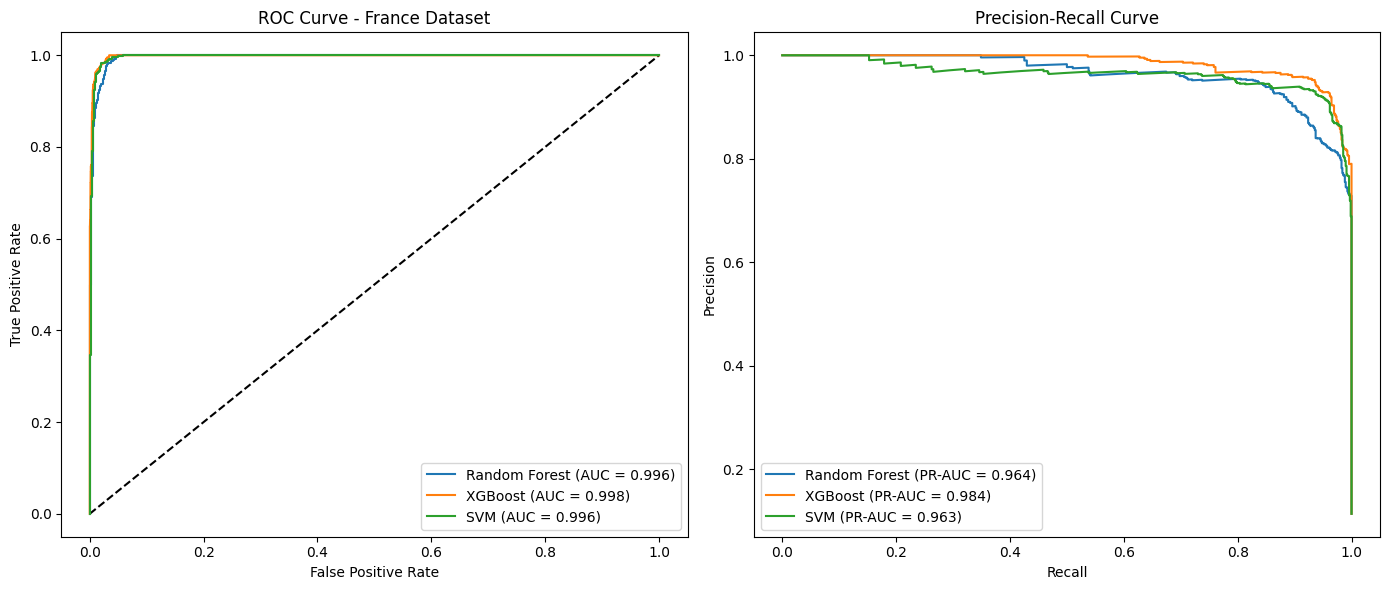


Performance Metrics:
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
      XGBoost  0.986000   0.957187 0.917889  0.937126 0.998025 0.984324
          SVM  0.984833   0.912134 0.958944  0.934954 0.996359 0.963296
Random Forest  0.976667   0.877437 0.923754  0.900000 0.995597 0.963824


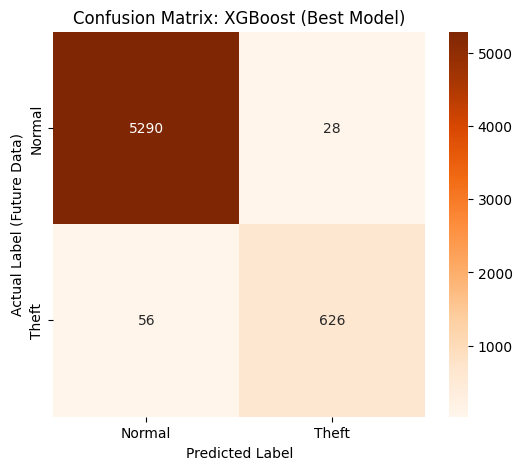

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import optuna

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)

import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Keep output clean

# ==========================================
# 1. LOAD DATA & HANDLE TIME-SERIES
# ==========================================
print("Loading France high-frequency dataset...")
df = pd.read_csv("France processed data.csv")

# Ensure temporal order for leakage prevention
if 'DateTime' in df.columns:
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df = df.sort_values('DateTime')

# Subset data to make SVM and Optuna feasible (last 30,000 rows)
print("Subsetting to the most recent 30,000 records for SVM feasibility...")
df = df.tail(30000).reset_index(drop=True)

# Drop non-numeric and datetime columns (Typo fixed here!)
cols_to_drop = ['Date', 'Time', 'DateTime', 'Season', 'User_Category']
X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Generate synthetic 'FLAG' using Isolation Forest (Top 5% anomalies)
print("Generating synthetic anomaly targets (Theft) via Isolation Forest...")
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
X_raw['FLAG'] = iso.fit_predict(X_raw)
X_raw['FLAG'] = X_raw['FLAG'].apply(lambda x: 1 if x == -1 else 0)

print(f"Class Distribution:\n{X_raw['FLAG'].value_counts()}")

# ==========================================
# 2. CHRONOLOGICAL SPLIT (LEAKAGE-FREE)
# ==========================================
print("\nPerforming Leakage-Free Chronological Split...")
X = X_raw.drop(columns=['FLAG'])
y = X_raw['FLAG']

# Split: First 80% Train, Last 20% Test (Strict Timeline)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Robust Scaling (Best for physical smart meter spikes)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. OPTUNA BAYESIAN OPTIMIZATION
# ==========================================
print("\nStarting Bayesian Optimization with Optuna...")
best_models = {}

# 3A. Random Forest Optimization
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight="balanced", random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds, zero_division=0)

print("Tuning Random Forest...")
rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=5, show_progress_bar=True)
best_models["Random Forest"] = RandomForestClassifier(**rf_study.best_params, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

# 3B. XGBoost Optimization
def xgb_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
    model = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, scale_pos_weight=19, eval_metric="logloss", random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds, zero_division=0)

print("Tuning XGBoost...")
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=5, show_progress_bar=True)
best_models["XGBoost"] = XGBClassifier(**xgb_study.best_params, scale_pos_weight=19, eval_metric="logloss", random_state=42).fit(X_train_scaled, y_train)

# 3C. SVM Optimization
def svm_objective(trial):
    C = trial.suggest_float('C', 0.1, 10, log=True)
    model = SVC(C=C, class_weight="balanced", probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds, zero_division=0)

print("Tuning SVM (This may take a moment)...")
svm_study = optuna.create_study(direction='maximize')
svm_study.optimize(svm_objective, n_trials=3, show_progress_bar=True)
best_models["SVM"] = SVC(**svm_study.best_params, class_weight="balanced", probability=True, random_state=42).fit(X_train_scaled, y_train)

# ==========================================
# 4. EVALUATION & VISUALIZATION
# ==========================================
print("\n\nEvaluating Models on Future Test Set...")

results = []
plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
ax1.plot([0, 1], [0, 1], 'k--')
ax2 = plt.subplot(1, 2, 2)

for name, model in tqdm(best_models.items(), desc="Calculating Metrics"):
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, probs)

    pr_prec, pr_rec, _ = precision_recall_curve(y_test, probs)
    pr_auc_score = auc(pr_rec, pr_prec)

    results.append([name, acc, prec, rec, f1, roc_auc, pr_auc_score])

    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    ax2.plot(pr_rec, pr_prec, label=f"{name} (PR-AUC = {pr_auc_score:.3f})")

ax1.set_title("ROC Curve - France Dataset")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Display Results Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"])
print("\nPerformance Metrics:")
print(results_df.sort_values(by="F1-Score", ascending=False).to_string(index=False))

# Confusion Matrix for Best Model
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = best_models[best_model_name]
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)")
plt.ylabel('Actual Label (Future Data)')
plt.xlabel('Predicted Label')
plt.show()

Loading Multi-Region dataset...
Generating synthetic 'FLAG' targets via Isolation Forest...
Class Distribution:
FLAG
0    18600
1     1400
Name: count, dtype: int64

One-Hot Encoding categorical features...
Performing Leakage-Free Group Split (Grouped by Customer_ID)...

Starting Exhaustive Grid Search Optimization...


Optimizing Models: 100%|██████████| 3/3 [04:01<00:00, 80.36s/it]




Evaluating Models on Multi-Region Test Set...


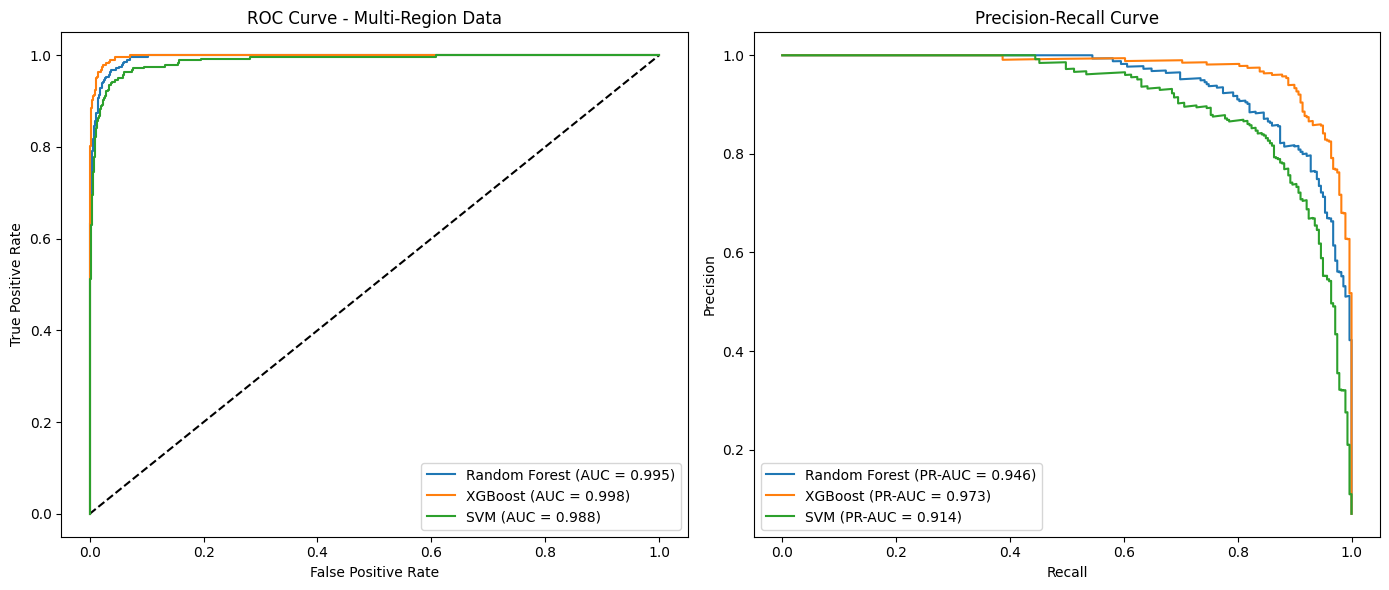


Performance Metrics:
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
      XGBoost   0.98325   0.831250 0.953405  0.888147 0.997652 0.972896
Random Forest   0.98075   0.865942 0.856631  0.861261 0.994780 0.945604
          SVM   0.94025   0.540161 0.964158  0.692407 0.987897 0.913623


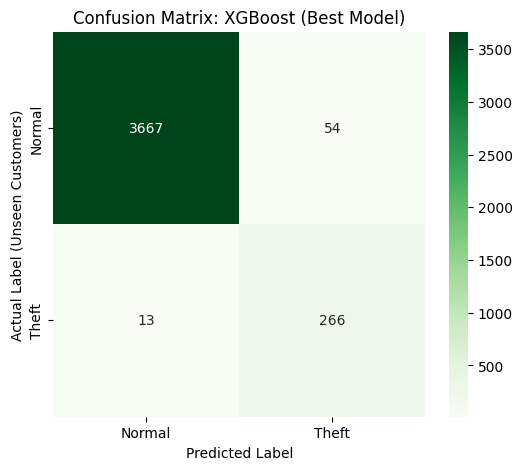

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD DATA & GENERATE SYNTHETIC LABELS
# ==========================================
print("Loading Multi-Region dataset...")
# FIXED: Using read_excel instead of read_csv for .xlsx files
df = pd.read_excel("/content/Synthetic_MultiRegion_ETD_Dataset.xlsx")

# Generate Synthetic Labels (Top 7% anomalies as 'Theft')
# We only use numeric columns to find the statistical anomalies
print("Generating synthetic 'FLAG' targets via Isolation Forest...")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Month' in numeric_cols: numeric_cols.remove('Month') # Keep month as context, not purely numeric anomaly

iso = IsolationForest(contamination=0.07, random_state=42, n_jobs=-1)
df['FLAG'] = iso.fit_predict(df[numeric_cols])
df['FLAG'] = df['FLAG'].apply(lambda x: 1 if x == -1 else 0)

print(f"Class Distribution:\n{df['FLAG'].value_counts()}")

# ==========================================
# 2. PREPROCESSING & CATEGORICAL ENCODING
# ==========================================
print("\nOne-Hot Encoding categorical features...")
# Drop Date to avoid temporal memorization, keep Customer_ID for grouping
df_processed = df.drop(columns=['Date'])

# One-hot encode Region, Consumer_Category, and Season
df_processed = pd.get_dummies(df_processed, columns=['Region', 'Consumer_Category', 'Season'], drop_first=True)

# ==========================================
# 3. LEAKAGE-FREE SPLIT (BY CUSTOMER)
# ==========================================
print("Performing Leakage-Free Group Split (Grouped by Customer_ID)...")
X = df_processed.drop(columns=['FLAG', 'Customer_ID'])
y = df_processed['FLAG']
groups = df_processed['Customer_ID']

# GroupShuffleSplit ensures a single customer is entirely in train OR test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Robust Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. GRID SEARCH EXHAUSTIVE OPTIMIZATION
# ==========================================
print("\nStarting Exhaustive Grid Search Optimization...")

# We use smaller, highly targeted grids since GridSearch is computationally heavy
models_params = {
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [10, 15], 'min_samples_split': [2, 5]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", scale_pos_weight=13, random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    "SVM": (
        SVC(class_weight="balanced", probability=True, random_state=42),
        {'C': [1, 10], 'gamma': ['scale', 0.1]}
    )
}

best_models = {}

# Use tqdm to track grid search across the models
for name, (model, params) in tqdm(models_params.items(), desc="Optimizing Models"):
    # cv=3 for speed, scoring='f1' to focus on theft class
    search = GridSearchCV(model, params, scoring='f1', cv=3, n_jobs=-1)
    search.fit(X_train_scaled, y_train)
    best_models[name] = search.best_estimator_

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
print("\n\nEvaluating Models on Multi-Region Test Set...")

results = []
plt.figure(figsize=(14, 6))

# ROC Subplot
ax1 = plt.subplot(1, 2, 1)
ax1.plot([0, 1], [0, 1], 'k--')

# PR Subplot
ax2 = plt.subplot(1, 2, 2)

for name, model in best_models.items():
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, probs)

    pr_prec, pr_rec, _ = precision_recall_curve(y_test, probs)
    pr_auc_score = auc(pr_rec, pr_prec)

    results.append([name, acc, prec, rec, f1, roc_auc, pr_auc_score])

    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    ax2.plot(pr_rec, pr_prec, label=f"{name} (PR-AUC = {pr_auc_score:.3f})")

ax1.set_title("ROC Curve - Multi-Region Data")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Display Results Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"])
print("\nPerformance Metrics:")
print(results_df.sort_values(by="F1-Score", ascending=False).to_string(index=False))

# Confusion Matrix for Best Model
best_model_name = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]["Model"]
best_model = best_models[best_model_name]
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Theft'], yticklabels=['Normal', 'Theft'])
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)")
plt.ylabel('Actual Label (Unseen Customers)')
plt.xlabel('Predicted Label')
plt.show()